In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('train_data.csv')

df.head()

,FarmerID,State,REGION,SEX,CITY,Zipcode,DISTRICT,VILLAGE,MARITAL_STATUS,Location,...,Rabi Seasons Agro Ecological Sub Zone in 2020,Rabi Seasons Seasonal average groundwater thickness (cm) in 2020,Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2020,Night light index,Village score based on socio-economic parameters (Non normalised),Village score based on socio-economic parameters (0 to 100),"Village category based on socio-economic parameters (Good, Average, Poor)",Land Holding Index source (Total Agri Area/ no of people),Road density (Km/ SqKm),Target_Variable/Total Income
0,1887256993454030,ODISHA,EAST,M,MALKANGIRI,764045,MALKANGIRI,Malkangiri,M,NaN,...,EASTERN PLATEAU (CHHOTANAGPUR) AND EASTERN GHA...,66.75,31.60,0.86,31.72,48.66,Average,0.62,5.49,1580000
1,1106879440316580,TELANGANA,SOUTH,M,MAHABUBABAD,506101,MAHABUBABAD,Mahabubabad,M,NaN,...,DECCAN PLATEAU (TELANGANA) AND EASTERN GHATS ...,76.50,20.65,0.70,30.79,47.16,Average,17.30,4.09,1000000
2,3650476011422490,TELANGANA,SOUTH,M,PENPAHAD,508201,SURYAPET,Lingala,M,"16.8379908,79.7474909",...,DECCAN PLATEAU (TELANGANA) AND EASTERN GHATS ...,73.84,15.88,0.89,23.80,35.82,Poor,0.64,2.14,1152000
3,1663099265314970,UTTAR PRADESH,NORTH,M,MAINPURI,205001,MAINPURI,Lalupura,M,"27.2387764,79.0699846",...,NORTHERN PLAIN (AND CENTRAL HIGHLANDS) INCLUDI...,45.35,5.19,0.95,25.07,37.89,Poor,0.02,0.00,600000
4,3523662478105830,MADHYA PRADESH,CENTRAL,M,PIPARIYA,461990,HOSHANGABAD,Amgaon,M,NaN,...,EASTERN PLATEAU (CHHOTANAGPUR) AND EASTERN GHA...,99.30,19.06,0.98,26.73,40.57,Average,0.14,2.97,970000


In [3]:
# Change this:
# cat_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
# To this:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
# Skewed columns
skewed_cols = [
    'Non_Agriculture_Income',
    'Total_Land_For_Agriculture',
    'Target_Variable/Total Income',
    'Avg_Disbursement_Amount_Bureau'
]

# Agricultural columns
agri_keywords = ['Kharif', 'Rabi', 'Agri', 'Rainfall', 'temperature', 'groundwater', 'Irrigated']

agri_cols = [
    col for col in df.select_dtypes(include=['number']).columns
    if any(kw in col for kw in agri_keywords)
]

# Numeric columns
all_numeric = df.select_dtypes(include=['number']).columns.tolist()

# Stable columns
stable_cols = [
    col for col in all_numeric
    if col not in skewed_cols and col not in agri_cols
]

In [4]:
for col in cat_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

In [5]:
for col in skewed_cols:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

In [6]:
for col in stable_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

In [7]:
from sklearn.impute import KNNImputer

if agri_cols:
    knn_imputer = KNNImputer(n_neighbors=5)
    df[agri_cols] = knn_imputer.fit_transform(df[agri_cols])

In [8]:
df.isnull().sum().sum()


np.int64(0)

In [9]:
def cap_outliers_iqr(dataframe, columns):
    df_capped = dataframe.copy()

    for col in columns:
        if col in df_capped.columns:
            Q1 = df_capped[col].quantile(0.25)
            Q3 = df_capped[col].quantile(0.75)

            IQR = Q3 - Q1

            lower_bound = min(0, Q1 - 1.5 * IQR)
            upper_bound = Q3 + 1.5 * IQR

            df_capped[col] = np.where(
                df_capped[col] < lower_bound,
                lower_bound,
                np.where(
                    df_capped[col] > upper_bound,
                    upper_bound,
                    df_capped[col]
                )
            )

    return df_capped

In [10]:
df_final = cap_outliers_iqr(df, all_numeric)

df_final.head()

,FarmerID,State,REGION,SEX,CITY,Zipcode,DISTRICT,VILLAGE,MARITAL_STATUS,Location,...,Rabi Seasons Agro Ecological Sub Zone in 2020,Rabi Seasons Seasonal average groundwater thickness (cm) in 2020,Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2020,Night light index,Village score based on socio-economic parameters (Non normalised),Village score based on socio-economic parameters (0 to 100),"Village category based on socio-economic parameters (Good, Average, Poor)",Land Holding Index source (Total Agri Area/ no of people),Road density (Km/ SqKm),Target_Variable/Total Income
0,1.887257e+15,ODISHA,EAST,M,MALKANGIRI,628383.5,MALKANGIRI,Malkangiri,M,"23.855855855855857,78.7455814494491",...,EASTERN PLATEAU (CHHOTANAGPUR) AND EASTERN GHA...,66.75,31.60,0.86,31.72,48.66,Average,0.62,5.49,1580000.0
1,1.106879e+15,TELANGANA,SOUTH,M,MAHABUBABAD,506101.0,MAHABUBABAD,Mahabubabad,M,"23.855855855855857,78.7455814494491",...,DECCAN PLATEAU (TELANGANA) AND EASTERN GHATS ...,76.50,20.65,0.70,30.79,47.16,Average,1.21,4.09,1000000.0
2,3.650476e+15,TELANGANA,SOUTH,M,PENPAHAD,508201.0,SURYAPET,Lingala,M,"16.8379908,79.7474909",...,DECCAN PLATEAU (TELANGANA) AND EASTERN GHATS ...,73.84,15.88,0.89,23.80,35.82,Poor,0.64,2.14,1152000.0
3,1.663099e+15,UTTAR PRADESH,NORTH,M,MAINPURI,205001.0,MAINPURI,Lalupura,M,"27.2387764,79.0699846",...,NORTHERN PLAIN (AND CENTRAL HIGHLANDS) INCLUDI...,45.35,5.19,0.95,25.07,37.89,Poor,0.02,0.00,600000.0
4,3.523662e+15,MADHYA PRADESH,CENTRAL,M,PIPARIYA,461990.0,HOSHANGABAD,Amgaon,M,"23.855855855855857,78.7455814494491",...,EASTERN PLATEAU (CHHOTANAGPUR) AND EASTERN GHA...,99.30,19.06,0.98,26.73,40.57,Average,0.14,2.97,970000.0


In [11]:
# --- PHASE 1.5: CREATING NEW FEATURES ---
print("Creating custom financial and agricultural ratios...")

# 1. Income per unit of land (Avoid dividing by zero with +1)
if 'Total_Land_For_Agriculture' in df_final.columns and 'Non_Agriculture_Income' in df_final.columns:
    df_final['Non_Agri_Per_Acre'] = df_final['Non_Agriculture_Income'] / (df_final['Total_Land_For_Agriculture'] + 1)

# 2. Total resource index
if 'Rabi Seasons Seasonal average groundwater thickness (cm) in 2020' in df_final.columns:
    # Combining water availability with land size
    df_final['Land_x_Water'] = df_final['Total_Land_For_Agriculture'] * df_final['Rabi Seasons Seasonal average groundwater thickness (cm) in 2020']

print("New features added to df_final!")

Creating custom financial and agricultural ratios...
New features added to df_final!


In [12]:
cols_to_drop = [
    'FarmerID',
    'Zipcode',
    'CITY',
    'DISTRICT',
    'VILLAGE',
    'K022-Nearest Mandi Name'
]

cols_to_drop = [col for col in cols_to_drop if col in df_final.columns]

df_engineered = df_final.drop(columns=cols_to_drop)

In [13]:
# --- ONE-HOT ENCODING FOR REGIONS ---
print("Splitting REGION into separate 1/0 columns...")

if 'REGION' in df_engineered.columns:
    df_engineered = pd.get_dummies(df_engineered, columns=['REGION'], dtype=int)
    print("REGION column successfully split!")

Splitting REGION into separate 1/0 columns...
REGION column successfully split!


In [14]:
from sklearn.preprocessing import LabelEncoder

# Just use 'object' (and 'category' if you have categorical types)
cat_cols = df_engineered.select_dtypes(include=['object']).columns.tolist()

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_engineered[col] = le.fit_transform(df_engineered[col].astype(str))
    label_encoders[col] = le

In [15]:
target_col = 'Target_Variable/Total Income'

X = df_engineered.drop(columns=[target_col])
y = df_engineered[target_col]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
y_train_log = np.log1p(y_train)

In [ ]:
# Install xgboost if you haven't already: !pip install xgboost
from xgboost import XGBRegressor

print("Training XGBoost Regressor (Optimized for low error)...")

xgb_model = XGBRegressor(
   n_estimators=500,        
    learning_rate=0.03,      
    max_depth=7,             
    subsample=1.0,           
    colsample_bytree=0.9,    
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train_log)

Training XGBoost Regressor (Optimized for low error)...


In [ ]:
y_pred_log = xgb_model.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"MAPE: {mape * 100:.2f}%")
print(f"R2 Score: {r2 * 100:.2f}%")
print(f"MAE: ₹{mae:,.2f}")
print(f"RMSE: ₹{rmse:,.2f}")

MAPE: 21.02%
R2 Score: 53.69%
MAE: ₹211,559.90
RMSE: ₹309,166.76


In [ ]:
df_engineered



,State,SEX,MARITAL_STATUS,Location,Address type,Ownership,No_of_Active_Loan_In_Bureau,Avg_Disbursement_Amount_Bureau,Non_Agriculture_Income,Total_Land_For_Agriculture,...,Land Holding Index source (Total Agri Area/ no of people),Road density (Km/ SqKm),Target_Variable/Total Income,Non_Agri_Per_Acre,Land_x_Water,REGION_CENTRAL,REGION_EAST,REGION_NORTH,REGION_SOUTH,REGION_WEST
0,11,1,0,20570,2,0,0.0,129500.00000,600000.0,13.0,...,0.62,5.49,1580000.0,42857.142857,867.75,0,1,0,0,0
1,14,1,0,20570,2,0,0.0,129500.00000,600000.0,5.0,...,1.21,4.09,1000000.0,100000.000000,382.50,0,0,0,1,0
2,14,1,0,6371,2,0,1.0,204000.00000,320000.0,8.0,...,0.64,2.14,1152000.0,35555.555556,590.72,0,0,0,1,0
3,15,1,0,26225,2,0,0.0,129500.00000,320400.0,6.0,...,0.02,0.00,600000.0,45771.428571,272.10,0,0,1,0,0
4,9,1,0,20570,2,0,0.0,129500.00000,0.0,5.0,...,0.14,2.97,970000.0,0.000000,496.50,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43168,9,1,0,20570,2,0,5.0,19666.66667,180000.0,10.0,...,0.27,0.00,810000.0,16363.636364,991.40,1,0,0,0,0
43169,11,1,0,14335,2,0,0.0,129500.00000,510000.0,8.0,...,0.46,2.81,780000.0,56666.666667,770.48,0,1,0,0,0
43170,0,1,0,20570,2,0,3.0,104333.33330,0.0,10.0,...,0.09,0.00,700000.0,0.000000,740.60,0,0,0,1,0
43171,9,1,0,20570,2,0,0.0,129500.00000,200000.0,10.0,...,0.62,0.00,800000.0,18181.818182,801.40,1,0,0,0,0


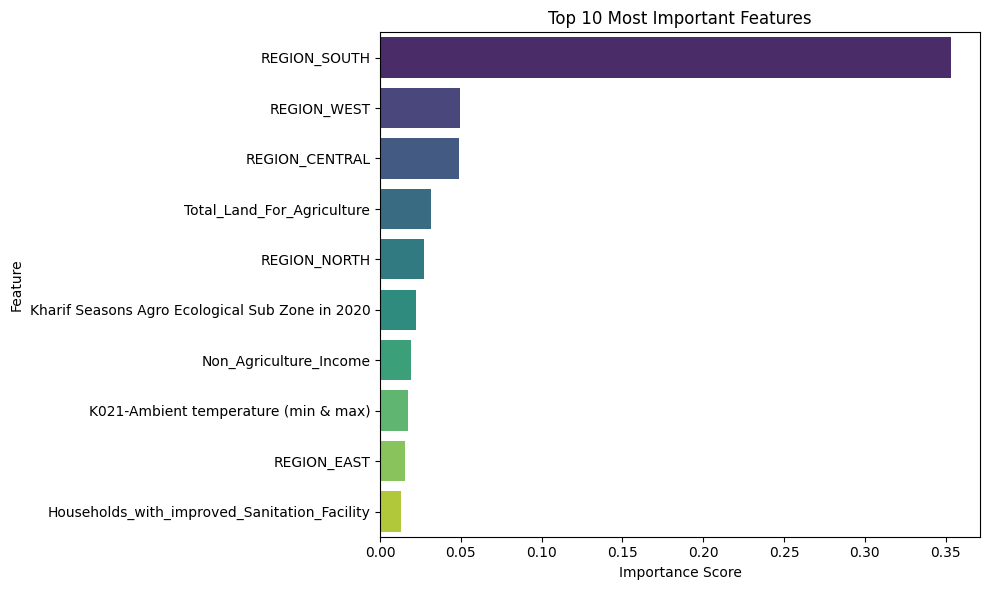

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    hue='Feature',
    data=feature_importances.head(10),
    palette='viridis',
    legend=False
)

plt.title('Top 10 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

Generating Boxplots for Outlier Detection on df_engineered...


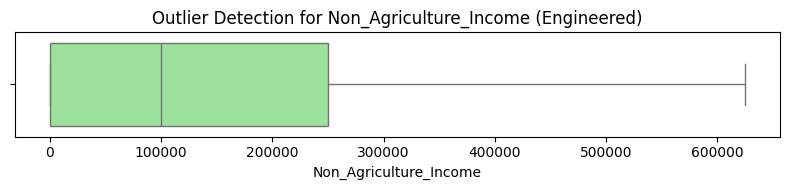

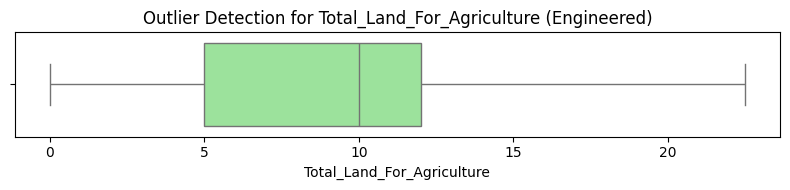

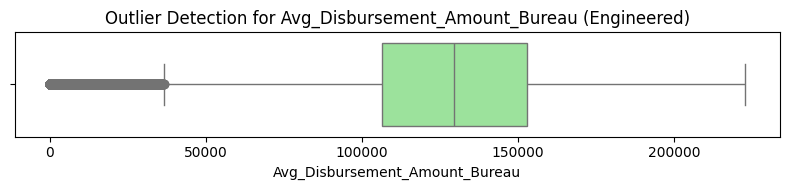


Generating Scatter Plot on df_engineered...


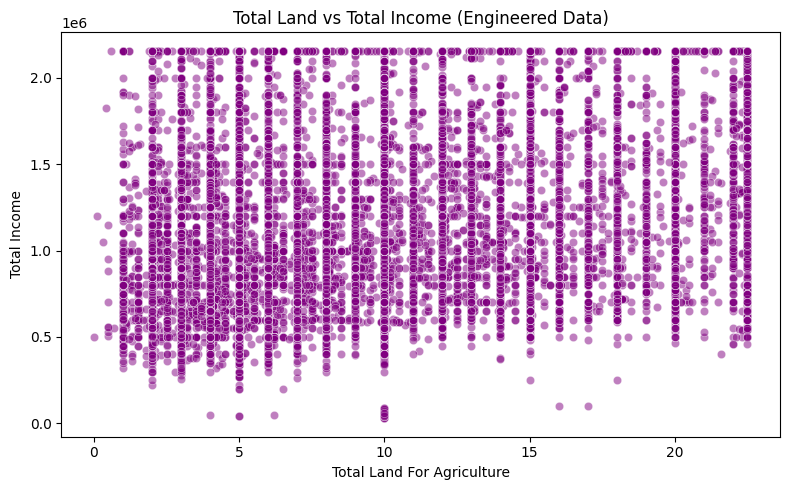


Generating Correlation Matrix on df_engineered...


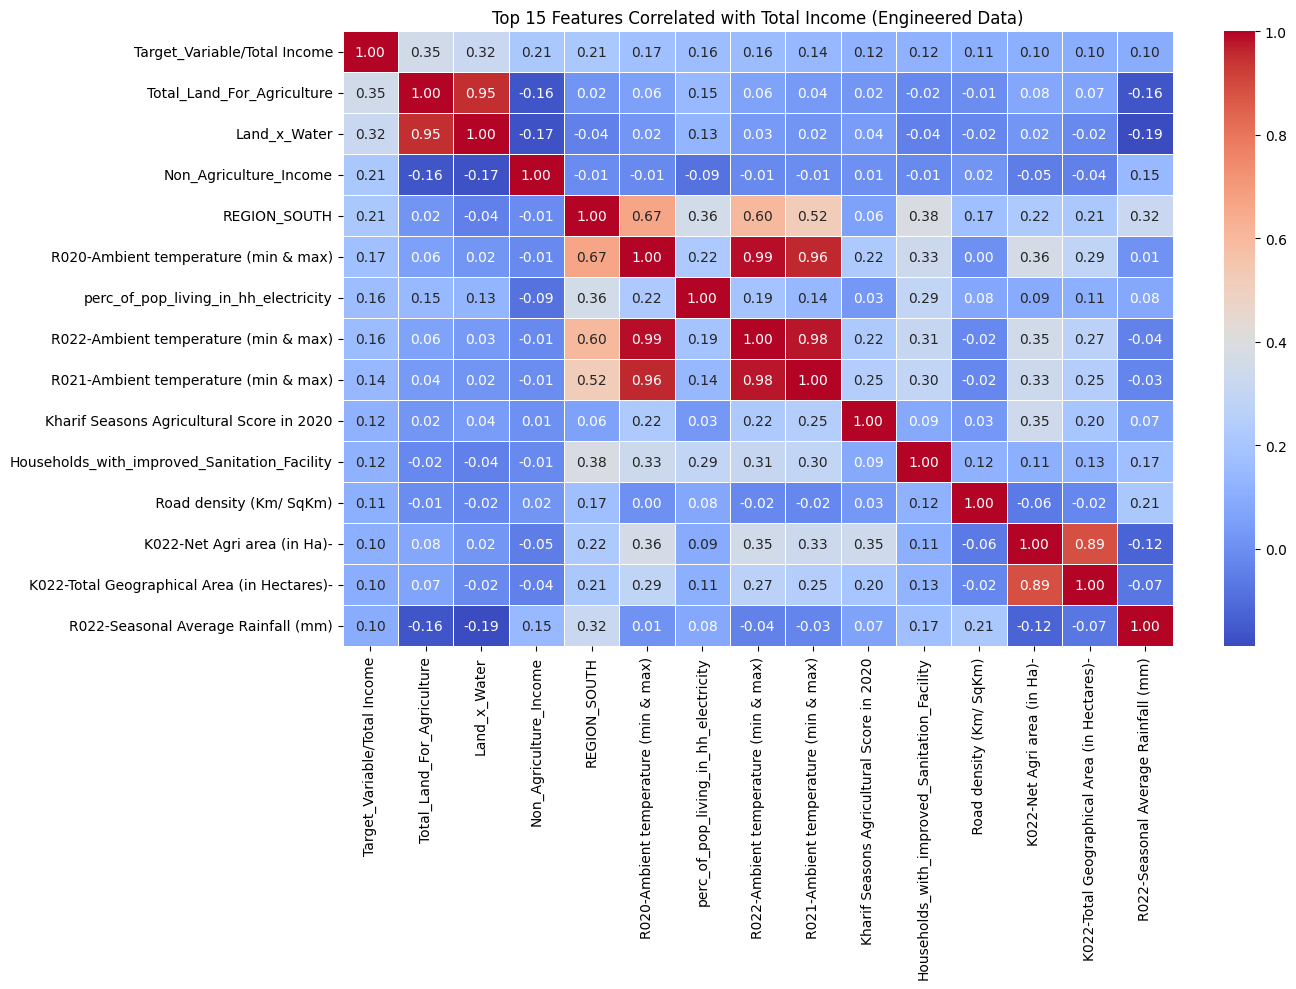

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the target variable
target_var = 'Target_Variable/Total Income'

# ==========================================
# 1. Boxplots for Outlier Detection
# ==========================================
print("Generating Boxplots for Outlier Detection on df_engineered...")

# Selected a few key numerical features to check for outliers
# You can easily add more columns to this list based on your needs
numerical_features = [
    'Non_Agriculture_Income', 
    'Total_Land_For_Agriculture', 
    'Avg_Disbursement_Amount_Bureau'
]

for feature in numerical_features:
    if feature in df_engineered.columns:
        plt.figure(figsize=(8, 2))
        sns.boxplot(x=df_engineered[feature].dropna(), color='lightgreen')
        plt.title(f'Outlier Detection for {feature} (Engineered)')
        plt.xlabel(feature)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Warning: Column '{feature}' not found in df_engineered.")

# ==========================================
# 2. Scatter Plots vs Target Variable
# ==========================================
print("\nGenerating Scatter Plot on df_engineered...")

if 'Total_Land_For_Agriculture' in df_engineered.columns and target_var in df_engineered.columns:
    plt.figure(figsize=(8, 5))
    # Plotting Land Size vs Income to observe the direct relationship
    sns.scatterplot(x='Total_Land_For_Agriculture', y=target_var, data=df_engineered, alpha=0.5, color='purple')
    plt.title('Total Land vs Total Income (Engineered Data)')
    plt.xlabel('Total Land For Agriculture')
    plt.ylabel('Total Income')
    plt.tight_layout()
    plt.show()
else:
    print("Warning: Missing columns required for the scatter plot.")

# ==========================================
# 3. Correlation Matrix
# ==========================================
print("\nGenerating Correlation Matrix on df_engineered...")

# Select only numerical columns to avoid calculation errors
numeric_df = df_engineered.select_dtypes(include=['number'])

if not numeric_df.empty and target_var in numeric_df.columns:
    plt.figure(figsize=(14, 10))
    
    # Calculate the correlation matrix
    corr_matrix = numeric_df.corr()
    
    # Isolate the top 15 features most highly correlated with the target variable
    top_corr_features = corr_matrix.nlargest(15, target_var)[target_var].index
    
    # Plot the heatmap for these top features
    sns.heatmap(
        numeric_df[top_corr_features].corr(), 
        annot=True,          # Show the correlation values
        cmap='coolwarm',     # Color scheme
        fmt=".2f",           # Format to 2 decimal places
        linewidths=0.5
    )
    plt.title('Top 15 Features Correlated with Total Income (Engineered Data)')
    plt.tight_layout()
    plt.show()
else:
    print("Warning: No numerical columns found or target variable is missing/non-numeric.")

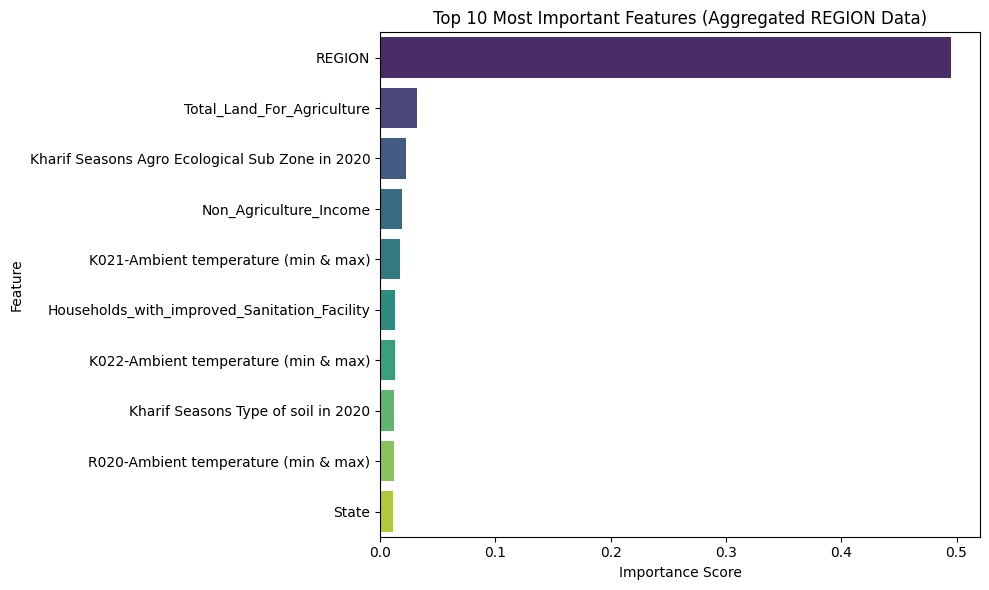

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Create the initial feature importance DataFrame
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

# 2. Identify all one-hot encoded REGION columns (e.g., REGION_EAST, REGION_NORTH, etc.)
region_cols = [col for col in feature_importances['Feature'] if col.startswith('REGION_')]

# 3. Sum their importance scores into a single 'REGION' entry
region_total_importance = feature_importances.loc[feature_importances['Feature'].isin(region_cols), 'Importance'].sum()

# 4. Remove the individual region columns and add the combined 'REGION' entry
feature_importances = feature_importances[~feature_importances['Feature'].isin(region_cols)].copy()

# Use pd.concat instead of append (which is deprecated in newer pandas versions)
new_row = pd.DataFrame({'Feature': ['REGION'], 'Importance': [region_total_importance]})
feature_importances = pd.concat([feature_importances, new_row], ignore_index=True)

# 5. Sort by importance again
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# 6. Plot the Top 10 including the combined REGION feature
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    hue='Feature',
    data=feature_importances.head(10),
    palette='viridis',
    legend=False
)

plt.title('Top 10 Most Important Features (Aggregated REGION Data)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [ ]:
#Upon the analysis of the previous datas,we conclude that Total_Land_For_Agriculture and Non_Agricultural_Income are the two main controllable features whose improvement leads to the overall increase in income.We avoid REGION and Kharif Seasons Agro Ecological Sub Zone in 2020 as they are  ot so controllable.

In [ ]:
import shap
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

Calculating SHAP values...


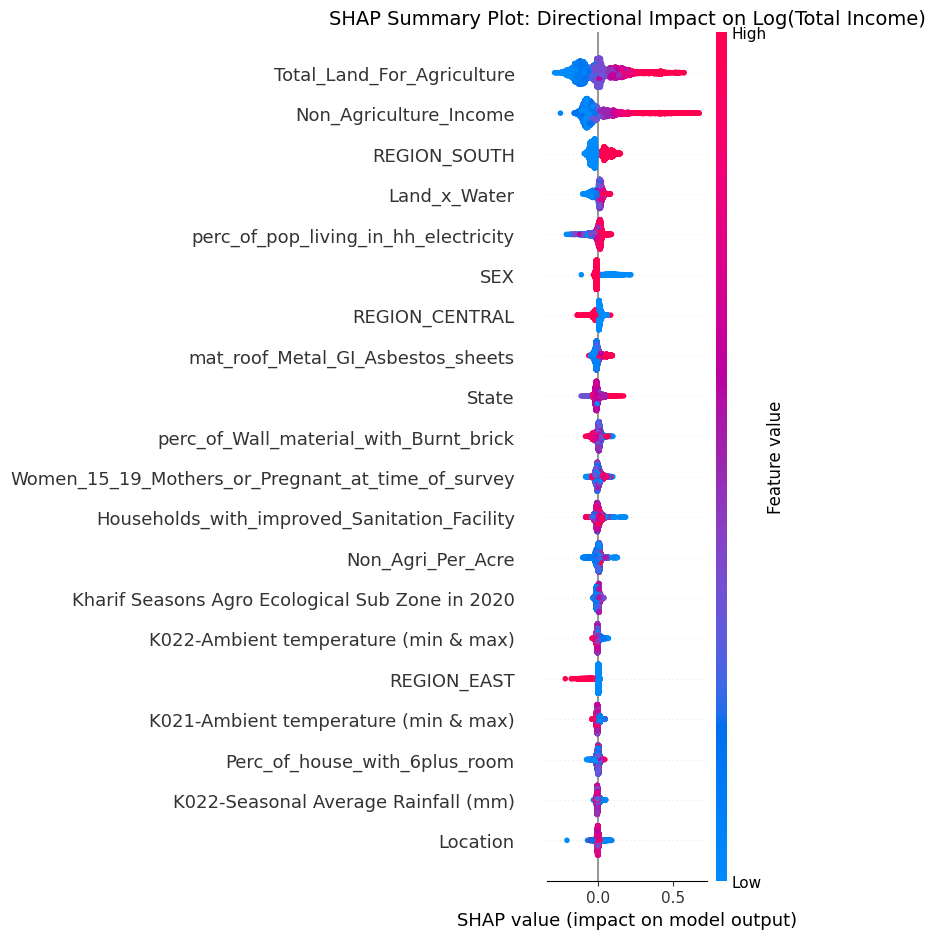

In [ ]:
print("Calculating SHAP values...")
# Initialize the TreeExplainer (optimized for tree-based models like XGBoost)
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Generate the SHAP Summary Plot
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot: Directional Impact on Log(Total Income)", fontsize=14)
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

Generating SHAP Dependence Plots for actionable levers...


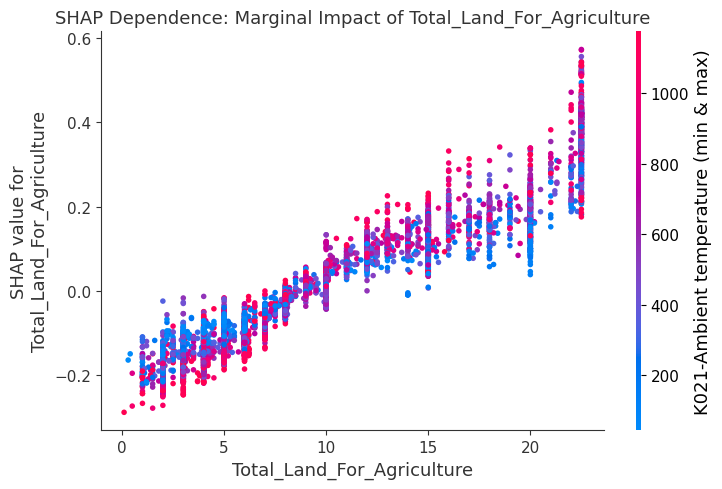

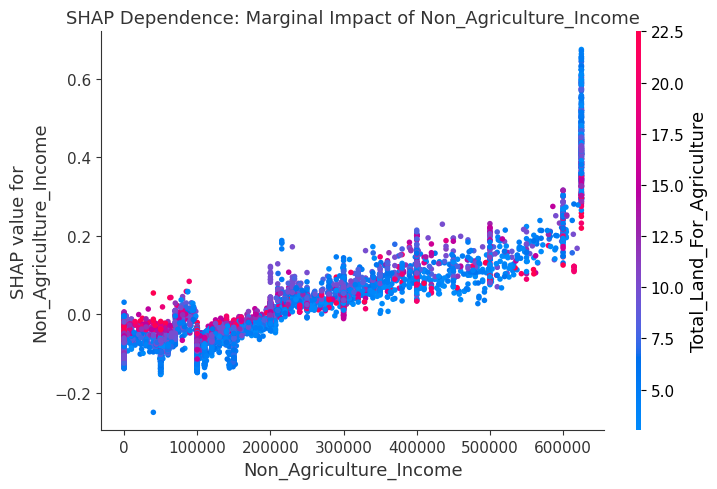

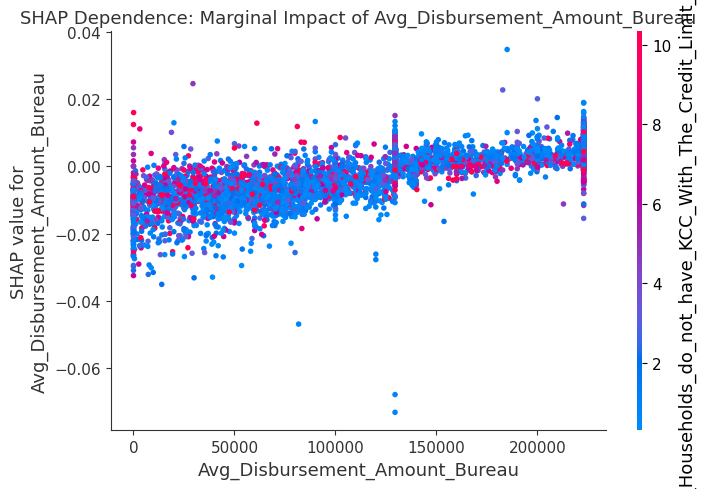

In [ ]:
# Define your most actionable levers based on your previous importance charts
actionable_levers = [
    'Total_Land_For_Agriculture', 
    'Non_Agriculture_Income', 
    'Avg_Disbursement_Amount_Bureau'
]

print("Generating SHAP Dependence Plots for actionable levers...")
for feature in actionable_levers:
    if feature in X_test.columns:
        # show=False allows us to control the plot sizing
        shap.dependence_plot(
            feature, 
            shap_values, 
            X_test, 
            title=f"SHAP Dependence: Marginal Impact of {feature}",
            show=False
        )
        plt.tight_layout()
        plt.show()

Generating Partial Dependence Plots (PDP)...


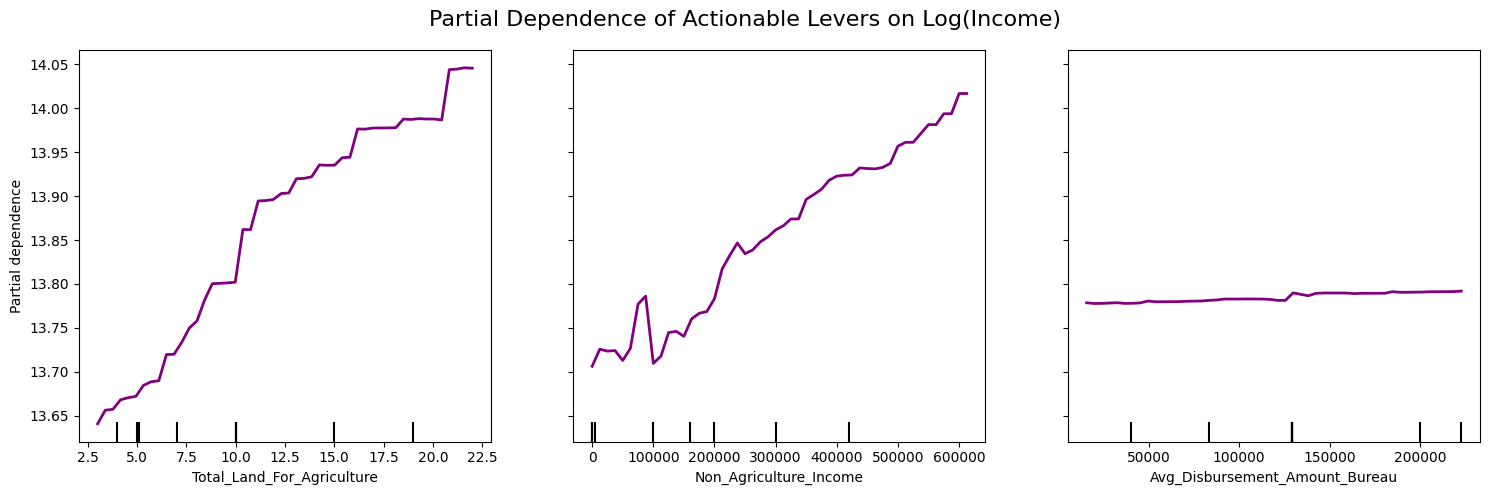

In [ ]:
print("Generating Partial Dependence Plots (PDP)...")

# We will plot the PDPs side-by-side for our actionable levers
fig, ax = plt.subplots(figsize=(15, 5))

# Generate the PDP using scikit-learn's built-in tool
PartialDependenceDisplay.from_estimator(
    estimator=xgb_model,
    X=X_train, # Using X_train to map the full distribution of the data
    features=actionable_levers,
    ax=ax,
    grid_resolution=50, # Controls the smoothness of the curve
    line_kw={"color": "purple", "linewidth": 2}
)

plt.suptitle('Partial Dependence of Actionable Levers on Log(Income)', fontsize=16)
plt.tight_layout()
plt.show()

Starting optimized SHAP calculation...
Calculation complete! Generating plots...


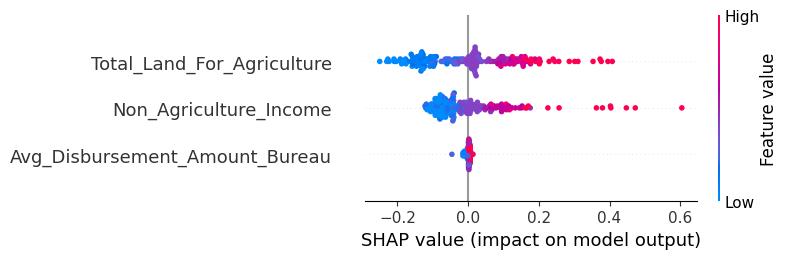

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# 1. Define controllable levers
controllable_levers = [
    'Avg_Disbursement_Amount_Bureau', 
    'Non_Agriculture_Income', 
    'Total_Land_For_Agriculture'
]

print("Starting optimized SHAP calculation...")

# 2. Optimization: Use a small sample of training data as the 'background' 
# This significantly speeds up the TreeExplainer
background_summary = shap.sample(X_train, 100)
explainer = shap.TreeExplainer(xgb_model, background_summary)

# 3. Optimization: Only explain a subset of the test set (e.g., 200 rows)
# This provides enough data for stable global insights without the long wait
X_test_small = X_test.head(200)

# 4. Optimization: Use check_additivity=False if you encounter technical mismatches
# with log-transformed targets
shap_values = explainer.shap_values(X_test_small, check_additivity=False)

print("Calculation complete! Generating plots...")

# 5. Visualize only the controllable levers
lever_indices = [X_test.columns.get_loc(c) for c in controllable_levers]

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values[:, lever_indices], 
    X_test_small[controllable_levers],
    plot_type="dot"
)
plt.show()

In [ ]:
####################################################################------PART B------####################################################################################

In [ ]:
import pandas as pd
import numpy as np

# 1. Define the specific mapping found in your CSV
# K = Kharif, R = Rabi | 022 = 2022, 021 = 2021, etc.
mapping = {
    '2022_Kharif': ('K022-Seasonal Average Rainfall (mm)', 'K022-Ambient temperature (min & max)'),
    '2022_Rabi': ('R022-Seasonal Average Rainfall (mm)', 'R022-Ambient temperature (min & max)'),
    '2021_Kharif': ('K021-Seasonal Average Rainfall (mm)', 'K021-Ambient temperature (min & max)'),
    '2021_Rabi': ('R021-Seasonal Average Rainfall (mm)', 'R021-Ambient temperature (min & max)'),
    '2020_Rabi': ('R020-Seasonal Average Rainfall (mm)', 'R020-Ambient temperature (min & max)')
}

# Helper to parse temperature ranges like "23.88 /30" into a single average
def parse_temp_range(val):
    if pd.isna(val) or not isinstance(val, str) or '/' not in val:
        return np.nan
    try:
        parts = val.split('/')
        nums = [float(p.strip()) for p in parts if p.strip()]
        return sum(nums) / len(nums) if nums else np.nan
    except:
        return np.nan

long_data = []

print("Reshaping wide format to panel...")
for key, (rain_col, temp_col) in mapping.items():
    year, season = key.split('_')
    if rain_col in df.columns and temp_col in df.columns:
        temp_df = df[['FarmerID', rain_col, temp_col]].copy()
        temp_df.columns = ['FarmerID', 'Rainfall', 'Temp_Raw']
        temp_df['Year'] = int(year)
        temp_df['Season'] = season
        long_data.append(temp_df)

# Create the Panel DataFrame
panel_df = pd.concat(long_data, ignore_index=True)

# Parse Temperature to Numeric
panel_df['Temperature'] = panel_df['Temp_Raw'].apply(parse_temp_range)
panel_df = panel_df.drop(columns=['Temp_Raw'])

# Sort chronologically for delta calculations
panel_df = panel_df.sort_values(by=['FarmerID', 'Year', 'Season'])

# --- 2. ENGINEER CLIMATE-DRIVEN VOLATILITY ---

# A. Year-over-Year Rainfall Delta (same season comparison)
panel_df['Rainfall_Delta'] = panel_df.groupby(['FarmerID', 'Season'])['Rainfall'].diff()

# B. Temperature Swing (Difference between Kharif and Rabi in same year)
seasonal_temp = panel_df.pivot_table(index=['FarmerID', 'Year'], columns='Season', values='Temperature').reset_index()
if 'Kharif' in seasonal_temp.columns and 'Rabi' in seasonal_temp.columns:
    seasonal_temp['Temp_Swing'] = (seasonal_temp['Kharif'] - seasonal_temp['Rabi']).abs()
    panel_df = panel_df.merge(seasonal_temp[['FarmerID', 'Year', 'Temp_Swing']], on=['FarmerID', 'Year'], how='left')

# C. Drought Frequency Proxy (Rainfall < 20th percentile across the whole dataset)
rain_threshold = panel_df['Rainfall'].quantile(0.20)
panel_df['Is_Drought'] = (panel_df['Rainfall'] < rain_threshold).astype(int)

# --- 3. AGGREGATE TO FARMER LEVEL ---
farmer_climate_features = panel_df.groupby('FarmerID').agg(
    Rainfall_Volatility=('Rainfall_Delta', 'std'),
    Max_Temp_Swing=('Temp_Swing', 'max'),
    Drought_Frequency_Proxy=('Is_Drought', 'sum')
).reset_index()

print("Panel data and volatility features engineered successfully.")
print(farmer_climate_features.head())

--- Testing Lever: Non_Agriculture_Income ---
Shift: Average (100,000) -> Good (249,700)
Projected Mean Income Gain: ₹134,192.34
Projected Percentage Uplift: 20.09%


In [ ]:
import pandas as pd
import numpy as np

# 1. Define the specific mapping found in your CSV
# K = Kharif, R = Rabi | 022 = 2022, 021 = 2021, etc.
mapping = {
    '2022_Kharif': ('K022-Seasonal Average Rainfall (mm)', 'K022-Ambient temperature (min & max)'),
    '2022_Rabi': ('R022-Seasonal Average Rainfall (mm)', 'R022-Ambient temperature (min & max)'),
    '2021_Kharif': ('K021-Seasonal Average Rainfall (mm)', 'K021-Ambient temperature (min & max)'),
    '2021_Rabi': ('R021-Seasonal Average Rainfall (mm)', 'R021-Ambient temperature (min & max)'),
    '2020_Rabi': ('R020-Seasonal Average Rainfall (mm)', 'R020-Ambient temperature (min & max)')
}

# Helper to parse temperature ranges like "23.88 /30" into a single average
def parse_temp_range(val):
    if pd.isna(val) or not isinstance(val, str) or '/' not in val:
        return np.nan
    try:
        parts = val.split('/')
        nums = [float(p.strip()) for p in parts if p.strip()]
        return sum(nums) / len(nums) if nums else np.nan
    except:
        return np.nan

long_data = []

print("Reshaping wide format to panel...")
for key, (rain_col, temp_col) in mapping.items():
    year, season = key.split('_')
    if rain_col in df.columns and temp_col in df.columns:
        temp_df = df[['FarmerID', rain_col, temp_col]].copy()
        temp_df.columns = ['FarmerID', 'Rainfall', 'Temp_Raw']
        temp_df['Year'] = int(year)
        temp_df['Season'] = season
        long_data.append(temp_df)

# Create the Panel DataFrame
panel_df = pd.concat(long_data, ignore_index=True)

# Parse Temperature to Numeric
panel_df['Temperature'] = panel_df['Temp_Raw'].apply(parse_temp_range)
panel_df = panel_df.drop(columns=['Temp_Raw'])

# Sort chronologically for delta calculations
panel_df = panel_df.sort_values(by=['FarmerID', 'Year', 'Season'])

# --- 2. ENGINEER CLIMATE-DRIVEN VOLATILITY ---

# A. Year-over-Year Rainfall Delta (same season comparison)
panel_df['Rainfall_Delta'] = panel_df.groupby(['FarmerID', 'Season'])['Rainfall'].diff()

# B. Temperature Swing (Difference between Kharif and Rabi in same year)
seasonal_temp = panel_df.pivot_table(index=['FarmerID', 'Year'], columns='Season', values='Temperature').reset_index()
if 'Kharif' in seasonal_temp.columns and 'Rabi' in seasonal_temp.columns:
    seasonal_temp['Temp_Swing'] = (seasonal_temp['Kharif'] - seasonal_temp['Rabi']).abs()
    panel_df = panel_df.merge(seasonal_temp[['FarmerID', 'Year', 'Temp_Swing']], on=['FarmerID', 'Year'], how='left')

# C. Drought Frequency Proxy (Rainfall < 20th percentile across the whole dataset)
rain_threshold = panel_df['Rainfall'].quantile(0.20)
panel_df['Is_Drought'] = (panel_df['Rainfall'] < rain_threshold).astype(int)

# --- 3. AGGREGATE TO FARMER LEVEL ---
farmer_climate_features = panel_df.groupby('FarmerID').agg(
    Rainfall_Volatility=('Rainfall_Delta', 'std'),
    Max_Temp_Swing=('Temp_Swing', 'max'),
    Drought_Frequency_Proxy=('Is_Drought', 'sum')
).reset_index()

print("Panel data and volatility features engineered successfully.")
print(farmer_climate_features.head())

Reshaping wide format to panel...
Panel data and volatility features engineered successfully.
           FarmerID  Rainfall_Volatility  Max_Temp_Swing  \
0  1000336362172130           275.218647           6.300   
1  1000733095118720           171.103149           4.480   
2  1001421387207060           279.567249           9.720   
3  1001466701508820           293.802475           2.075   
4  1002423170894490           198.321846           0.695   

   Drought_Frequency_Proxy  
0                        0  
1                        2  
2                        0  
3                        0  
4                        0  


In [ ]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv('train_data.csv')

# --- 1. Seasonal Income Split Ratio (Kharif vs. Rabi) ---
# We calculate what percentage of the annual agricultural potential comes from Kharif
k_22 = 'Kharif Seasons  Agricultural Score in 2022'
r_22 = 'Rabi Seasons Agricultural Score in 2022'

df['Total_Agri_Score_2022'] = df[k_22] + df[r_22]
# High value (>0.5) = Kharif dependent; Low value (<0.5) = Rabi dependent
df['Kharif_Income_Share'] = df[k_22] / df['Total_Agri_Score_2022']

# --- 2. Income Volatility Score ---
# We use all available seasonal scores (2020-2022) to measure the 'swing' in performance
score_cols = [
    'Kharif Seasons  Agricultural Score in 2022', 'Rabi Seasons Agricultural Score in 2022',
    'Kharif Seasons Agricultural Score in 2021', 'Rabi Seasons Agricultural Score in 2021',
    'Kharif Seasons Agricultural Score in 2020', 'Rabi Seasons Agricultural Score in 2020'
]
available_scores = [c for c in score_cols if c in df.columns]

# Volatility = Coefficient of Variation (Standard Deviation / Mean)
# This normalizes the risk regardless of whether the farmer is 'rich' or 'poor'
mean_score = df[available_scores].mean(axis=1)
std_score = df[available_scores].std(axis=1)
df['Income_Volatility_Score'] = std_score / mean_score

print(df[['FarmerID', 'Kharif_Income_Share', 'Income_Volatility_Score']].head())

           FarmerID  Kharif_Income_Share  Income_Volatility_Score
0  1887256993454030             0.575262                 0.275349
1  1106879440316580             0.547278                 0.120773
2  3650476011422490             0.387399                 0.311783
3  1663099265314970             0.548002                 0.256391
4  3523662478105830             0.739649                 0.417618


C:\Users\shiba\AppData\Local\Temp\ipykernel_23984\3457393635.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  demonstration_summary = df.groupby('Volatility_Tier').agg({
C:\Users\shiba\AppData\Local\Temp\ipykernel_23984\3457393635.py:51: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Volatility_Tier', y=income_col, data=df, palette='viridis', ci=None)


--- Data-Backed Demonstration: Impact of Instability ---
  Volatility_Tier  Target_Variable/Total Income  No_of_Active_Loan_In_Bureau  \
0          Stable                  1.291878e+06                     1.977222   
1        Moderate                  1.227096e+06                     1.770335   
2            High                  1.213901e+06                     1.728508   
3       Very High                  1.156418e+06                     1.666945   

   FarmerID  
0     10800  
1     10794  
2     10818  
3     10761  


C:\Users\shiba\AppData\Local\Temp\ipykernel_23984\3457393635.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Volatility_Tier', y=income_col, data=df, palette='viridis', ci=None)


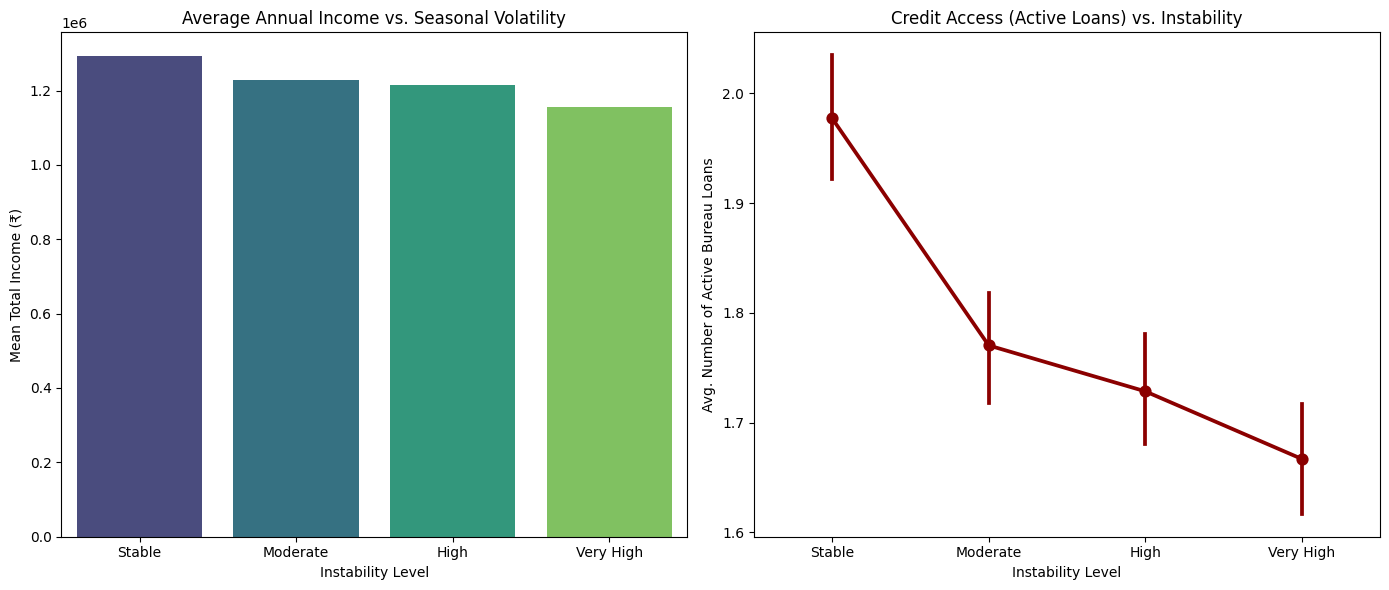


Conclusion: Farmers with 'Very High' instability earn 10.5% less than 'Stable' farmers, proving that volatility correlates with structural poverty.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('train_data.csv')

# 2. Re-engineer seasonal performance scores to calculate Volatility
# Note: Using Agricultural Scores as a proxy for earning potential
score_cols = [
    'Kharif Seasons  Agricultural Score in 2022', 
    'Rabi Seasons Agricultural Score in 2022',
    'Kharif Seasons Agricultural Score in 2021',
    'Rabi Seasons Agricultural Score in 2021',
    'Kharif Seasons Agricultural Score in 2020',
    'Rabi Seasons Agricultural Score in 2020'
]
# Filter to ensure we only use columns present in the file
available_scores = [c for c in score_cols if c in df.columns]

# Volatility Score = Coefficient of Variation (Standard Deviation / Mean)
# Higher score = More unstable/unpredictable income
mean_score = df[available_scores].mean(axis=1)
std_score = df[available_scores].std(axis=1)
df['Income_Volatility_Score'] = (std_score / mean_score).fillna(0)

# 3. Define the Anchors (Income and Risk Proxies)
income_col = 'Target_Variable/Total Income'
loan_col = 'No_of_Active_Loan_In_Bureau'

# Bin farmers into Volatility Quartiles
df['Volatility_Tier'] = pd.qcut(df['Income_Volatility_Score'], 4, 
                                labels=['Stable', 'Moderate', 'High', 'Very High'])

# 4. Statistical Demonstration (Anchoring Claims)
demonstration_summary = df.groupby('Volatility_Tier').agg({
    income_col: 'mean',
    loan_col: 'mean',
    'FarmerID': 'count'
}).reset_index()

print("--- Data-Backed Demonstration: Impact of Instability ---")
print(demonstration_summary)

# 5. Visualization: Proving the Income and Credit Gap
plt.figure(figsize=(14, 6))

# Plot A: Average Income Trend
plt.subplot(1, 2, 1)
sns.barplot(x='Volatility_Tier', y=income_col, data=df, palette='viridis', ci=None)
plt.title('Average Annual Income vs. Seasonal Volatility')
plt.xlabel('Instability Level')
plt.ylabel('Mean Total Income (₹)')

# Plot B: Active Loans (Credit Access Proxy)
plt.subplot(1, 2, 2)
sns.pointplot(x='Volatility_Tier', y=loan_col, data=df, color='darkred')
plt.title('Credit Access (Active Loans) vs. Instability')
plt.xlabel('Instability Level')
plt.ylabel('Avg. Number of Active Bureau Loans')

plt.tight_layout()
plt.savefig('volatility_demonstration.png')
plt.show()

# 6. Conclusion Output
low_vol_inc = demonstration_summary.iloc[0][income_col]
high_vol_inc = demonstration_summary.iloc[-1][income_col]
gap_pct = ((low_vol_inc - high_vol_inc) / low_vol_inc) * 100

print(f"\nConclusion: Farmers with 'Very High' instability earn {gap_pct:.1f}% less "
      f"than 'Stable' farmers, proving that volatility correlates with structural poverty.")